Iter 1/100, Best Cost: 340305.21332
Iter 2/100, Best Cost: 343591.28014
Iter 3/100, Best Cost: 349443.43000
Iter 4/100, Best Cost: 354949.15041
Iter 5/100, Best Cost: 355965.80235
Iter 6/100, Best Cost: 355965.80235
Iter 7/100, Best Cost: 355965.80235
Iter 8/100, Best Cost: 356487.78353
Iter 9/100, Best Cost: 356778.11482
Iter 10/100, Best Cost: 356778.11482
Iter 11/100, Best Cost: 356778.11482
Iter 12/100, Best Cost: 356911.52558
Iter 13/100, Best Cost: 357065.77116
Iter 14/100, Best Cost: 357065.77116
Iter 15/100, Best Cost: 357065.77116
Iter 16/100, Best Cost: 357065.77116
Iter 17/100, Best Cost: 357214.89717
Iter 18/100, Best Cost: 357214.89717
Iter 19/100, Best Cost: 357214.89717
Iter 20/100, Best Cost: 357214.89717
Iter 21/100, Best Cost: 357214.89717
Iter 22/100, Best Cost: 357214.89717
Iter 23/100, Best Cost: 357214.89717
Iter 24/100, Best Cost: 357300.48252
Iter 25/100, Best Cost: 357300.48252
Iter 26/100, Best Cost: 357300.48252
Iter 27/100, Best Cost: 357300.48252
Iter 28/10

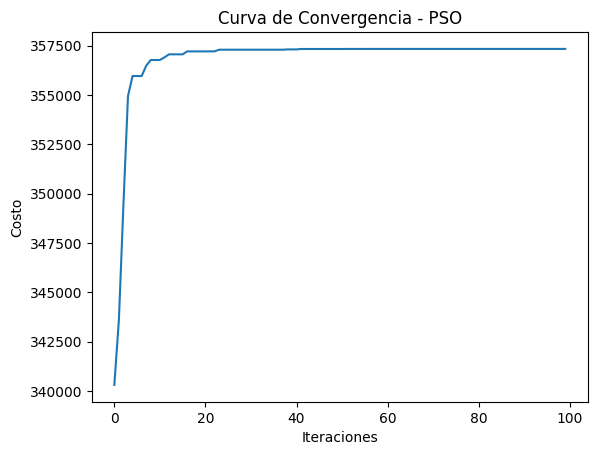

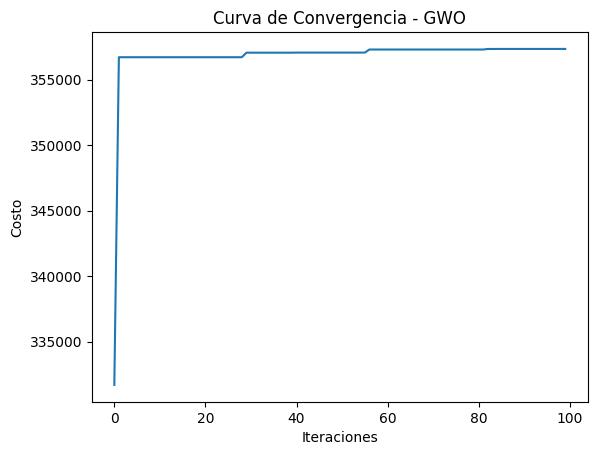

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def angulo_inc(lat, delta, omega, beta, gamma):
    beta=np.radians(beta) #Angulo entre el plano y la horizontal
    gamma=np.radians(gamma) #Azimuth

    cos_thi = (
    np.sin(delta)*np.sin(lat)*np.cos(beta)-np.sin(delta)*np.cos(lat)*np.sin(beta)*np.cos(gamma) +
    np.cos(delta)*np.cos(lat)*np.cos(beta)*np.cos(omega) + np.cos(delta)*np.sin(lat)*np.sin(beta)*np.cos(gamma)*np.cos(omega) +
    np.cos(delta)*np.sin(beta)*np.sin(gamma)*np.sin(omega))
    thi=np.arccos(cos_thi)
    return thi

def des_Irr(GHI, thz):
    Kt = GHI / (1367 * np.maximum(np.cos(thz), 0.065))
    Kt = np.clip(Kt, 0, 1)
    df = np.where(Kt <= 0.22, 1 - 0.09 * Kt,
    np.where(Kt <= 0.8, 0.9511 - 0.1604 * Kt + 4.388 * Kt**2 - 16.638 * Kt**3 + 12.336 * Kt**4,
    0.165))
    Gd = df * GHI
    Gb = GHI - Gd
    return Gb, Gd

def Irr_in(GHI_i, Gb, Gd, Rb, beta, sigma=0.2):
    beta = np.radians(beta)
    Gr = sigma * GHI_i * ((1 - np.cos(beta)) / 2)
    Gt = Gb * Rb + Gd * ((1 + np.cos(beta)) / 2) + Gr
    return Gt

def fitness(position, data, lat, Ap, At, eta):
    theta, beta, N = position
    N = int(round(N))
    A_total = N * Ap
    if A_total > At:
        return -np.inf


    E_total = 0.0
    for i, time in enumerate(data['Datetime']):
        h = time.hour + time.minute / 60
        n = time.timetuple().tm_yday

        delta = np.radians(23.45 * np.sin(np.radians((360 / 365) * (284 + n))))
        omega = np.radians(15 * (h - 12))
        # beta = np.radians(beta)
        # theta = np.radians(theta)   

        thz = np.arccos(np.sin(lat) * np.sin(delta) + np.cos(lat) * np.cos(delta) * np.cos(omega))
        thi = angulo_inc(lat, delta, omega, beta, theta)

        Rb = np.maximum(np.cos(thi) / np.cos(thz), 0)
        Gb, Gd = des_Irr(data['GHI'].iloc[i], thz)
        Gt = Irr_in(data['GHI'].iloc[i], Gb, Gd, Rb, beta)
        E_total += eta * A_total * Gt
    return E_total

# Clase PSO
class PSO:
    def __init__(self, fitness_func, n_dim, n_pop, max_iter, var_min, var_max, w_max, w_min, c1, c2, **fitness_args):
        self.fitness_func = fitness_func
        self.n_dim = n_dim
        self.n_pop = n_pop
        self.max_iter = max_iter
        self.var_min = np.array(var_min)
        self.var_max = np.array(var_max)
        self.w_max = w_max
        self.w_min = w_min
        self.c1 = c1
        self.c2 = c2
        self.fitness_args = fitness_args
        
        # Inicialización de partículas
        self.positions = np.random.uniform(self.var_min, self.var_max, (self.n_pop, self.n_dim))
        self.velocities = np.zeros((self.n_pop, self.n_dim))
        self.personal_best_positions = self.positions.copy()
        self.personal_best_scores = np.array([self.fitness_func(pos, **self.fitness_args) for pos in self.positions])
        self.global_best_position = self.personal_best_positions[np.argmax(self.personal_best_scores)].copy()
        self.global_best_score = np.max(self.personal_best_scores)
        
        # Curva de convergencia
        self.convergence_curve = []

    def optimize(self):
        for t in range(self.max_iter):
            w = self.w_max - t * (self.w_max - self.w_min) / self.max_iter
            for i in range(self.n_pop):
                r1, r2 = np.random.rand(self.n_dim), np.random.rand(self.n_dim)
                self.velocities[i] = (
                    w * self.velocities[i] +
                    self.c1 * r1 * (self.personal_best_positions[i] - self.positions[i]) +
                    self.c2 * r2 * (self.global_best_position - self.positions[i])
                )
                self.positions[i] += self.velocities[i]
                self.positions[i] = np.clip(self.positions[i], self.var_min, self.var_max)
                self.positions[i][2] = int(round(self.positions[i][2]))
                
                # Evaluar el costo
                current_score = self.fitness_func(self.positions[i], **self.fitness_args)
                if current_score > self.personal_best_scores[i]:
                    self.personal_best_scores[i] = current_score
                    self.personal_best_positions[i] = self.positions[i].copy()
                    if current_score > self.global_best_score:
                        self.global_best_score = current_score
                        self.global_best_position = self.positions[i].copy()
            
            # Guardar la mejor solución hasta ahora
            self.convergence_curve.append(self.global_best_score)
            print(f"Iter {t+1}/{self.max_iter}, Best Cost: {self.global_best_score:.5f}")
        
        return self.global_best_position

# Clase GWO 
class GWO:
    def __init__(self, fitness_func, n_dim, n_pop, max_iter, var_min, var_max, **fitness_args):
        self.fitness_func = fitness_func
        self.n_dim = n_dim
        self.n_pop = n_pop
        self.max_iter = max_iter
        self.var_min = np.array(var_min)
        self.var_max = np.array(var_max)
        self.fitness_args = fitness_args

        self.positions = np.random.uniform(self.var_min, self.var_max, (self.n_pop, self.n_dim))
        self.costs = np.array([self.fitness_func(pos, **self.fitness_args) for pos in self.positions])
        
        sort_indices = np.argsort(self.costs)[::-1]
        self.alpha_pos = self.positions[sort_indices[0]].copy()
        self.alpha_score = self.costs[sort_indices[0]]
        self.beta_pos = self.positions[sort_indices[1]].copy()
        self.beta_score = self.costs[sort_indices[1]]
        self.delta_pos = self.positions[sort_indices[2]].copy()
        self.delta_score = self.costs[sort_indices[2]]
        
        self.convergence_curve = []

    def optimize(self):
        for t in range(self.max_iter):
            a = 2 - t * (2 / self.max_iter)
            for i in range(self.n_pop):
                r1, r2 = np.random.rand(self.n_dim), np.random.rand(self.n_dim)
                A1, C1 = 2 * a * r1 - a, 2 * r2
                D_alpha = np.abs(C1 * self.alpha_pos - self.positions[i])
                x1 = self.alpha_pos - A1 * D_alpha

                r1, r2 = np.random.rand(self.n_dim), np.random.rand(self.n_dim)
                A2, C2 = 2 * a * r1 - a, 2 * r2
                D_beta = np.abs(C2 * self.beta_pos - self.positions[i])
                x2 = self.beta_pos - A2 * D_beta

                r1, r2 = np.random.rand(self.n_dim), np.random.rand(self.n_dim)
                A3, C3 = 2 * a * r1 - a, 2 * r2
                D_delta = np.abs(C3 * self.delta_pos - self.positions[i])
                x3 = self.delta_pos - A3 * D_delta

                self.positions[i] = (x1 + x2 + x3) / 3.0
                self.positions[i] = np.clip(self.positions[i], self.var_min, self.var_max)
                self.positions[i][2] = int(round(self.positions[i][2]))

            self.costs = np.array([self.fitness_func(pos, **self.fitness_args) for pos in self.positions])
            
            for i in range(self.n_pop):
                if self.costs[i] > self.alpha_score:
                    self.delta_score, self.delta_pos = self.beta_score, self.beta_pos.copy()
                    self.beta_score, self.beta_pos = self.alpha_score, self.alpha_pos.copy()
                    self.alpha_score, self.alpha_pos = self.costs[i], self.positions[i].copy()
                elif self.costs[i] > self.beta_score:
                    self.delta_score, self.delta_pos = self.beta_score, self.beta_pos.copy()
                    self.beta_score, self.beta_pos = self.costs[i], self.positions[i].copy()
                elif self.costs[i] > self.delta_score:
                    self.delta_score, self.delta_pos = self.costs[i], self.positions[i].copy()

            self.convergence_curve.append(self.alpha_score)
            print(f"Iter {t+1}/{self.max_iter}, Best Cost: {self.alpha_score:.5f}")

        return self.alpha_pos

# Parámetros iniciales
lat = np.radians(19.5111)
# lat = np.radians(lat)
Ap = 2
At = 100
eta = 0.4

csv_path = r"D:\Upiita\6to\IA\Prácticas\Paneles_Solares\POWER_Point_Hourly_20230101_20231231_019d51N_099d13W_LST.csv"
data = pd.read_csv(csv_path, skiprows=12)
data.columns = ['Year', 'Month', 'Day', 'Hour', 'GHI']
data = data[(data['Year'] == 2023) & (data['Month'] == 12) & (data['Day'] == 31)]
data['Datetime'] = pd.to_datetime(data[['Year', 'Month', 'Day', 'Hour']])

n_dim = 3
var_min = [0, -0, 1]
var_max = [360, 90, round(At / Ap)]
n_pop = 30
max_iter = 100

# PSO ejecución
w_max, w_min = 0.9, 0.4
c1 = c2 = 2.0

optimizer = PSO(
    fitness_func=fitness, n_dim=n_dim, n_pop=n_pop, max_iter=max_iter,
    var_min=var_min, var_max=var_max, w_max=w_max, w_min=w_min, c1=c1, c2=c2,
    data=data, lat=lat, Ap=Ap, At=At, eta=eta
)

best_position = optimizer.optimize()

# Graficar
plt.figure()
plt.plot(optimizer.convergence_curve)
plt.xlabel('Iteraciones')
plt.ylabel('Costo')
plt.title('Curva de Convergencia - PSO')
# plt.show()

print("Mejor posición encontrada:", best_position)

#GWO Ejecución

optimizer = GWO(
    fitness_func=fitness, n_dim=n_dim, n_pop=n_pop, max_iter=max_iter,
    var_min=var_min, var_max=var_max, data=data, lat=lat, Ap=Ap, At=At, eta=eta
)

best_position = optimizer.optimize()

# Graficar
plt.figure()
plt.plot(optimizer.convergence_curve)
plt.xlabel('Iteraciones')
plt.ylabel('Costo')
plt.title('Curva de Convergencia - GWO')

print("Mejor posición encontrada:", best_position)
plt.show()